# Cross-Dataset Model Analysis (H-CAST Baseline Style)

This notebook mirrors the structure of `hcast_analysis.ipynb`, but compares **models** across **datasets**. Experiment directories contain `seed_<seed>` children; curves and final metrics report the mean and sample standard deviation across seeds.

It includes:
- per-dataset validation curves (`FPA`, `wAP`, `TICE`, `AHD`),
- per-dataset training loss curves,
- per-level training/validation curves,
- final test comparison tables.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from model_comparison_utils import (
    ModelComparisonAnalysis,
    ModelComparisonConfig,
    build_model_dataset_run_specs,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
# -------- Configuration --------
OUTPUT_ROOT = OUTPUTS_ROOT

MODEL_COLORS = {
    'hcast': '#1f77b4',
    'hrn': '#ff7f0e',
    'ht_capsnet': '#2ca02c',
    'lhdnn': '#d62728',
    'hiercos': '#cad627',
}

# Manual mode: choose run-name tokens here; runs are searched as {model}_{dataset}.
AUTO_DISCOVER = False
INCLUDE_TOPDOWN_METRICS = True
DATASET_NAMES = ['cifar-100', 'cub-200-2011', 'fgvc-aircraft']  # cifar-100, cub-200-2011, fgvc-aircraft
MODEL_NAMES = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']       # hcast, lhdnn, hrn, ht_capsnet, hiercos

MODEL_RUN_NAMES = {
    'ht_capsnet': 'capsnet',
}
DATASET_RUN_NAMES = {}
MODEL_LABELS = {
    'hcast': 'H-CAST',
    'hrn': 'HRN',
    'ht_capsnet': 'HT-CapsNet',
    'lhdnn': 'LH-DNN',
    'hiercos': 'HierCoS',
}
DATASET_LABELS = {}
RUN_NAME_OVERRIDES = {}
RUN_LABEL_OVERRIDES = {}
RUN_COLOR_OVERRIDES = {}
EXTRA_RUNS = [
    'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf',
    'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf',
    'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf',
    'hrn_cub200_orthonormal_plugin_level_softmax_ce_reg_final_only_identity'
]

MANUAL_RUNS = build_model_dataset_run_specs(
    MODEL_NAMES,
    DATASET_NAMES,
    model_run_names=MODEL_RUN_NAMES,
    dataset_run_names=DATASET_RUN_NAMES,
    model_labels=MODEL_LABELS,
    dataset_labels=DATASET_LABELS,
    run_name_overrides=RUN_NAME_OVERRIDES,
    run_label_overrides=RUN_LABEL_OVERRIDES,
    run_color_overrides=RUN_COLOR_OVERRIDES,
) + EXTRA_RUNS
MANUAL_RUN_DIRS = []  # Path-only shorthand kept for quick ad hoc additions.

# Optional filters (leave empty = keep everything)
INCLUDE_MODELS = []   # hcast, hrn, ht_capsnet, lhdnn, hiercos
INCLUDE_DATASETS = []  # DATASET_NAMES already selects datasets in manual mode.
INCLUDE_RUN_NAME_SUBSTRINGS = []
EXCLUDE_RUN_NAME_SUBSTRINGS = []

# Use this only when auto-discovering base runs named as model_dataset.
REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT = False

PREFERRED_DATASET_ORDER = ['cifar-100', 'cub-200-2011', 'fgvc-aircraft']
PREFERRED_MODEL_ORDER = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']


In [3]:
config = ModelComparisonConfig(
    output_root=OUTPUT_ROOT,
    auto_discover=AUTO_DISCOVER,
    manual_runs=MANUAL_RUNS,
    manual_run_dirs=MANUAL_RUN_DIRS,
    include_models=INCLUDE_MODELS,
    include_datasets=INCLUDE_DATASETS,
    include_run_name_substrings=INCLUDE_RUN_NAME_SUBSTRINGS,
    exclude_run_name_substrings=EXCLUDE_RUN_NAME_SUBSTRINGS,
    require_model_dataset_run_name_format=REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    preferred_dataset_order=PREFERRED_DATASET_ORDER,
    preferred_model_order=PREFERRED_MODEL_ORDER,
    model_colors=MODEL_COLORS,
)

analysis = ModelComparisonAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_aircraft
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft
Candidate run directories: 15
Parsed runs: 14
Parse errors:
  - /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf: Seed configurations differ beyond allowed run fields: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_0 vs /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_1
Filtered runs: 14

Selected runs
-------------
CIFAR-100
  - H-CAST       | run=hcast_cifar100                      | seeds=[0, 1, 2] | best_td=89.3±9.7/0.7575 | best_ind=94.3±6.7/0.7391 | test_FPA_td=75.01% | test_FPA_ind=73.52%
  - LH-DNN       | run=lhdnn_cifar100                   

## Validation Metrics Curves (Per Dataset)

Interpretation note:
- For `FPA` and `wAP`, higher is better.
- For `TICE` and `AHD`, lower is better.
- Solid lines are top-down metrics; dashed lines are independent metrics.


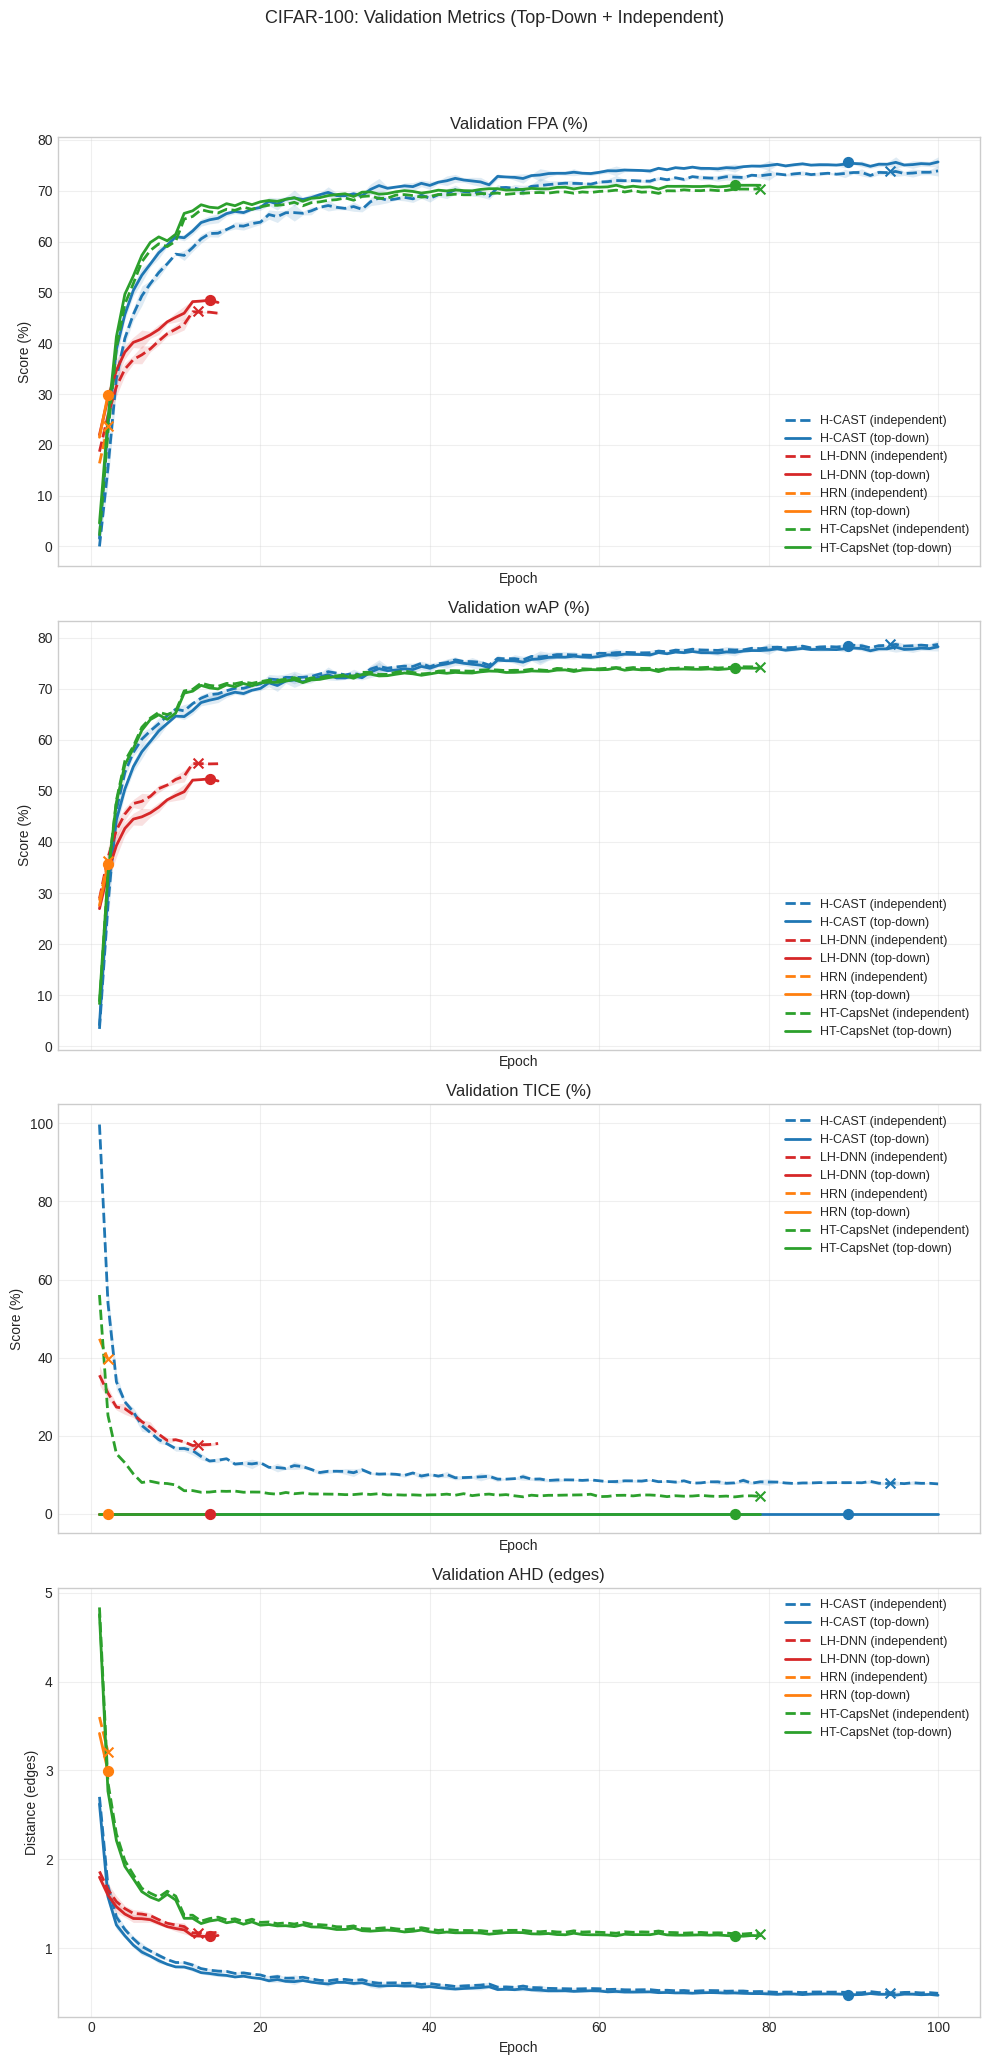

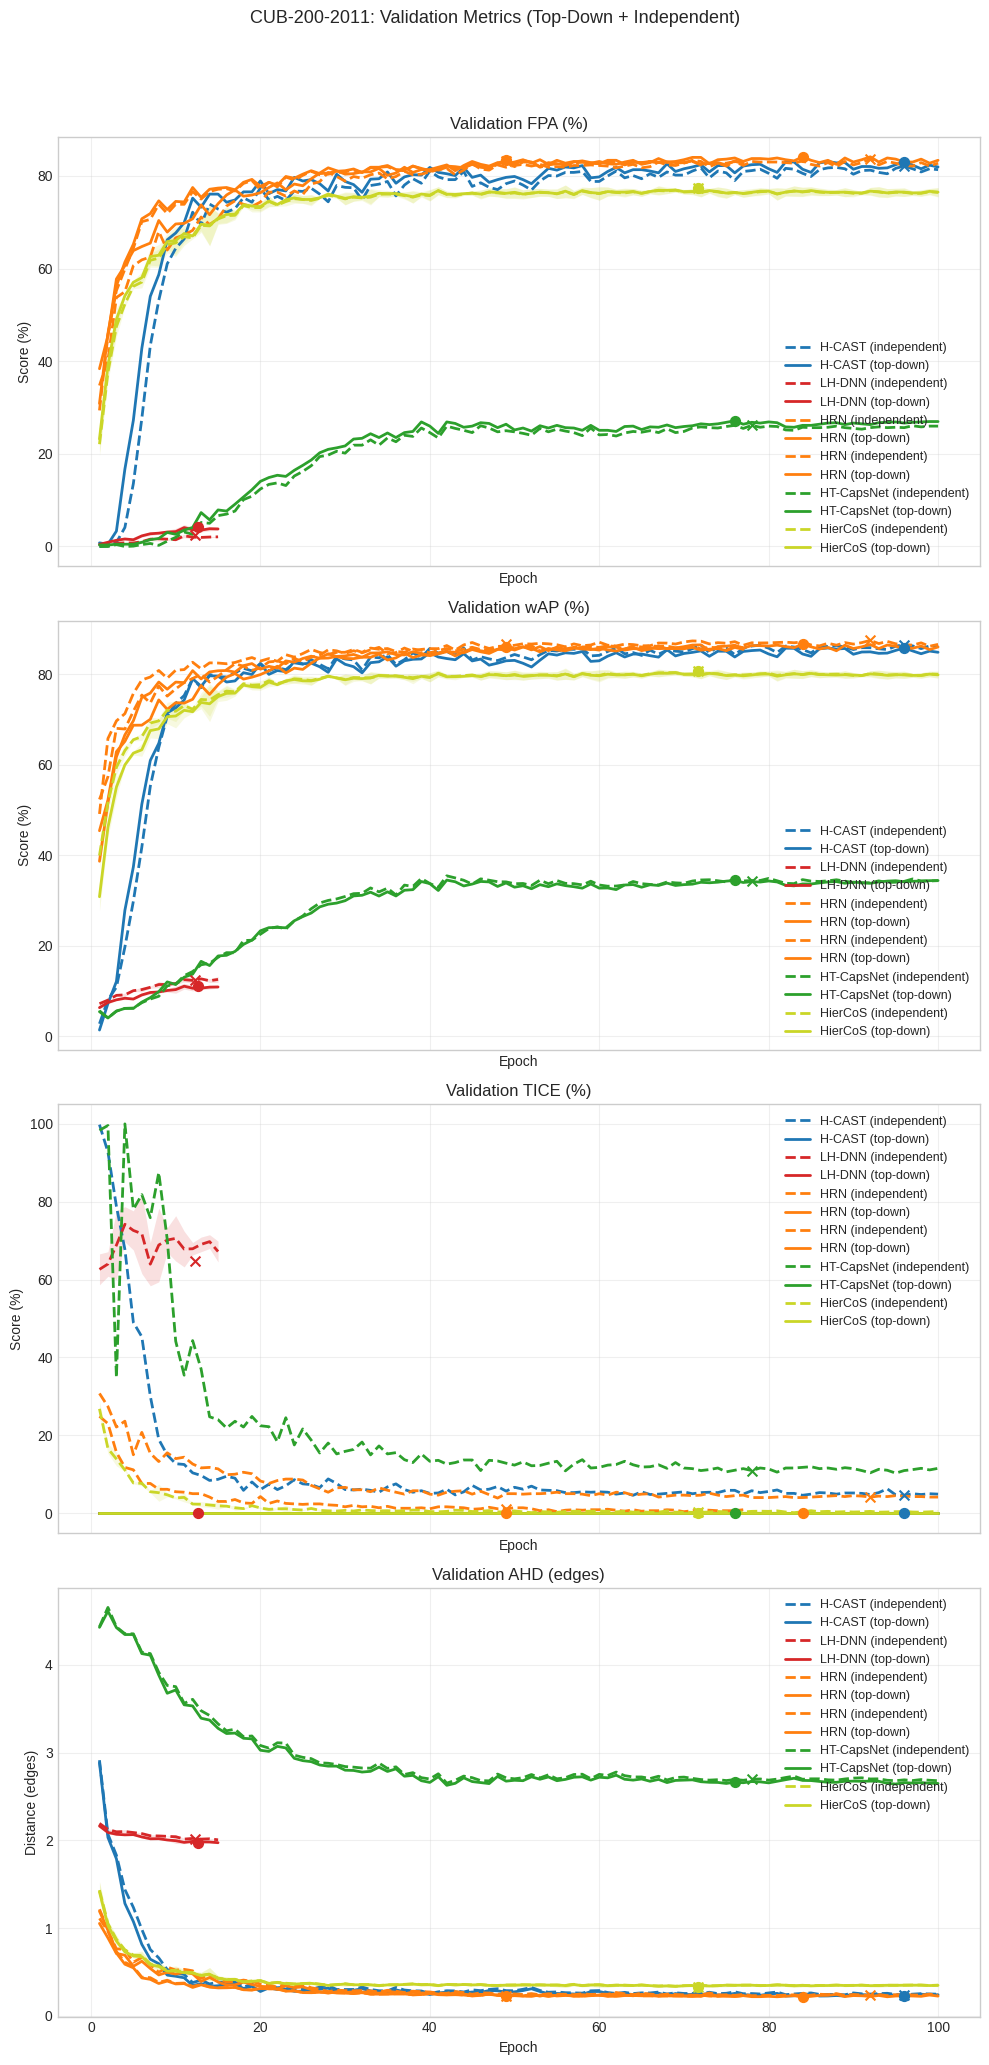

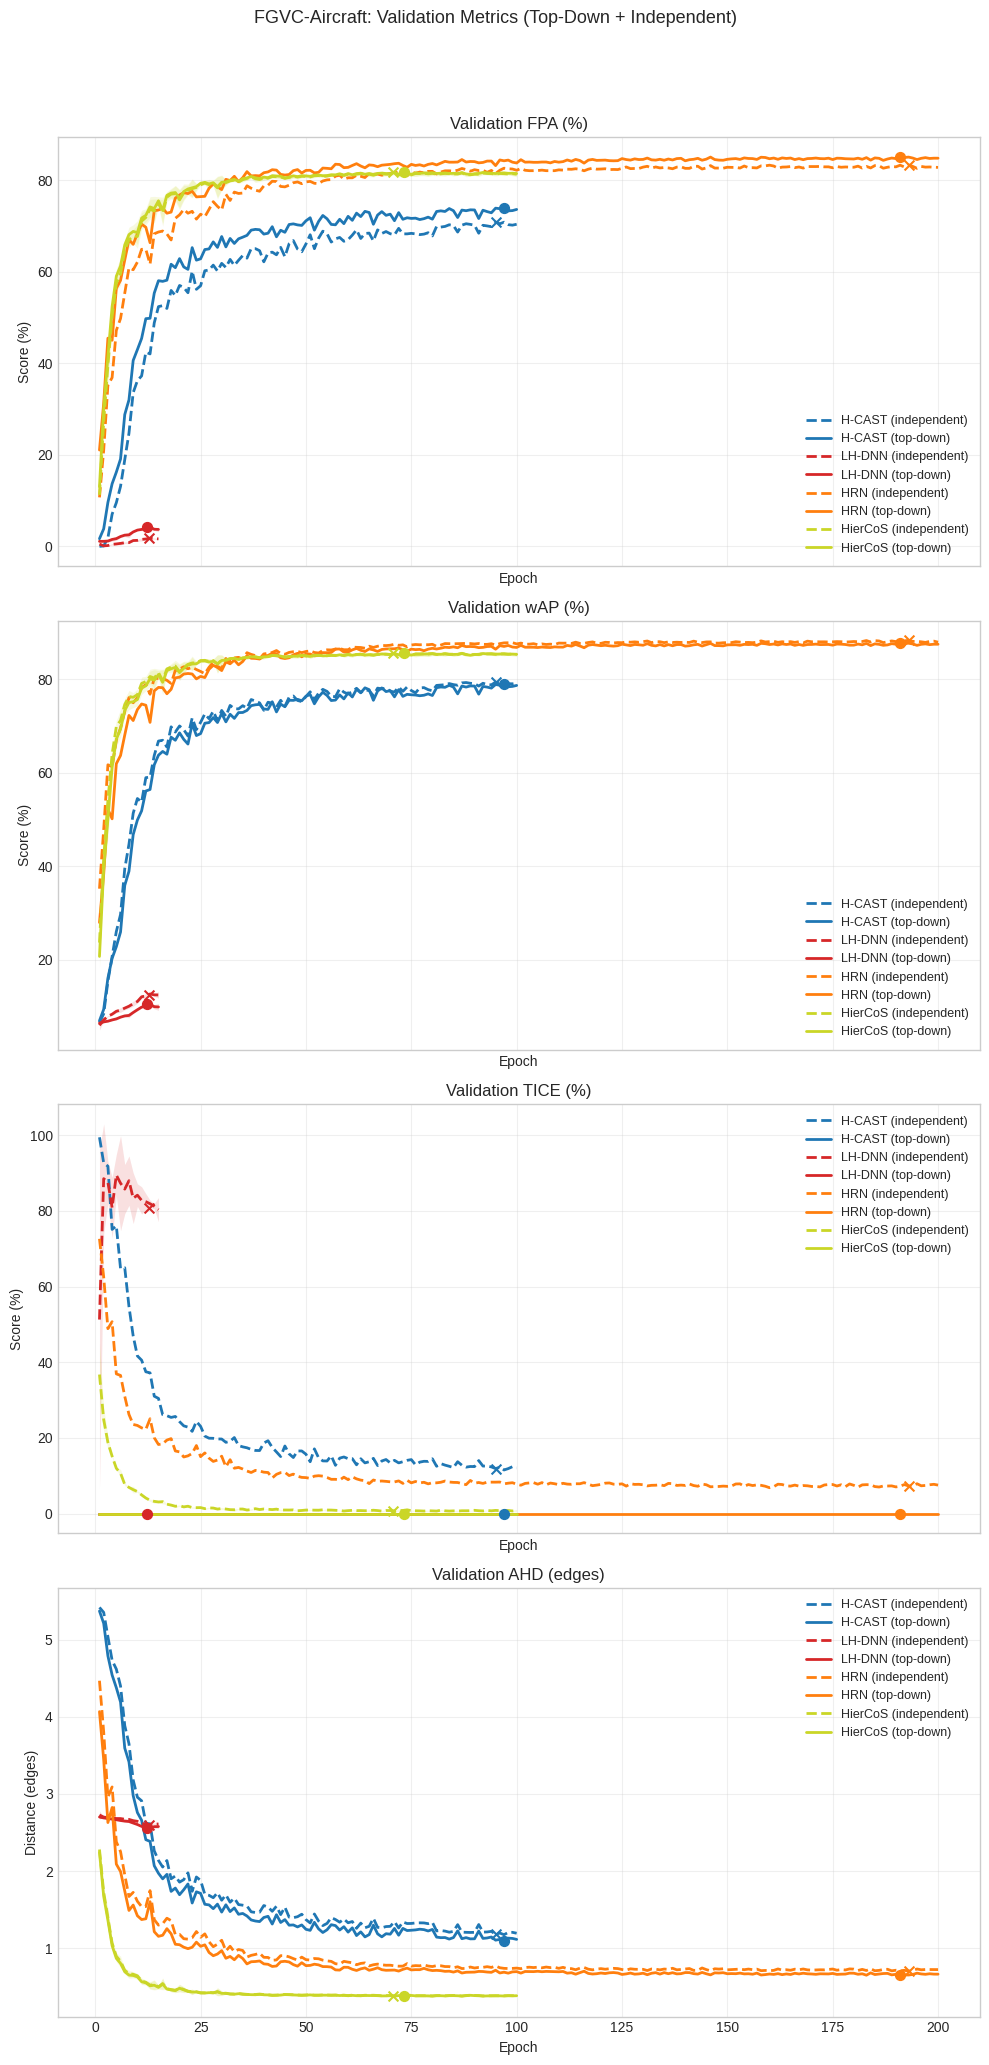

In [4]:
analysis.plot_validation_curves()


## Training Loss Comparison (Per Dataset)

Interpretation note:
- Lower is better for all loss curves.


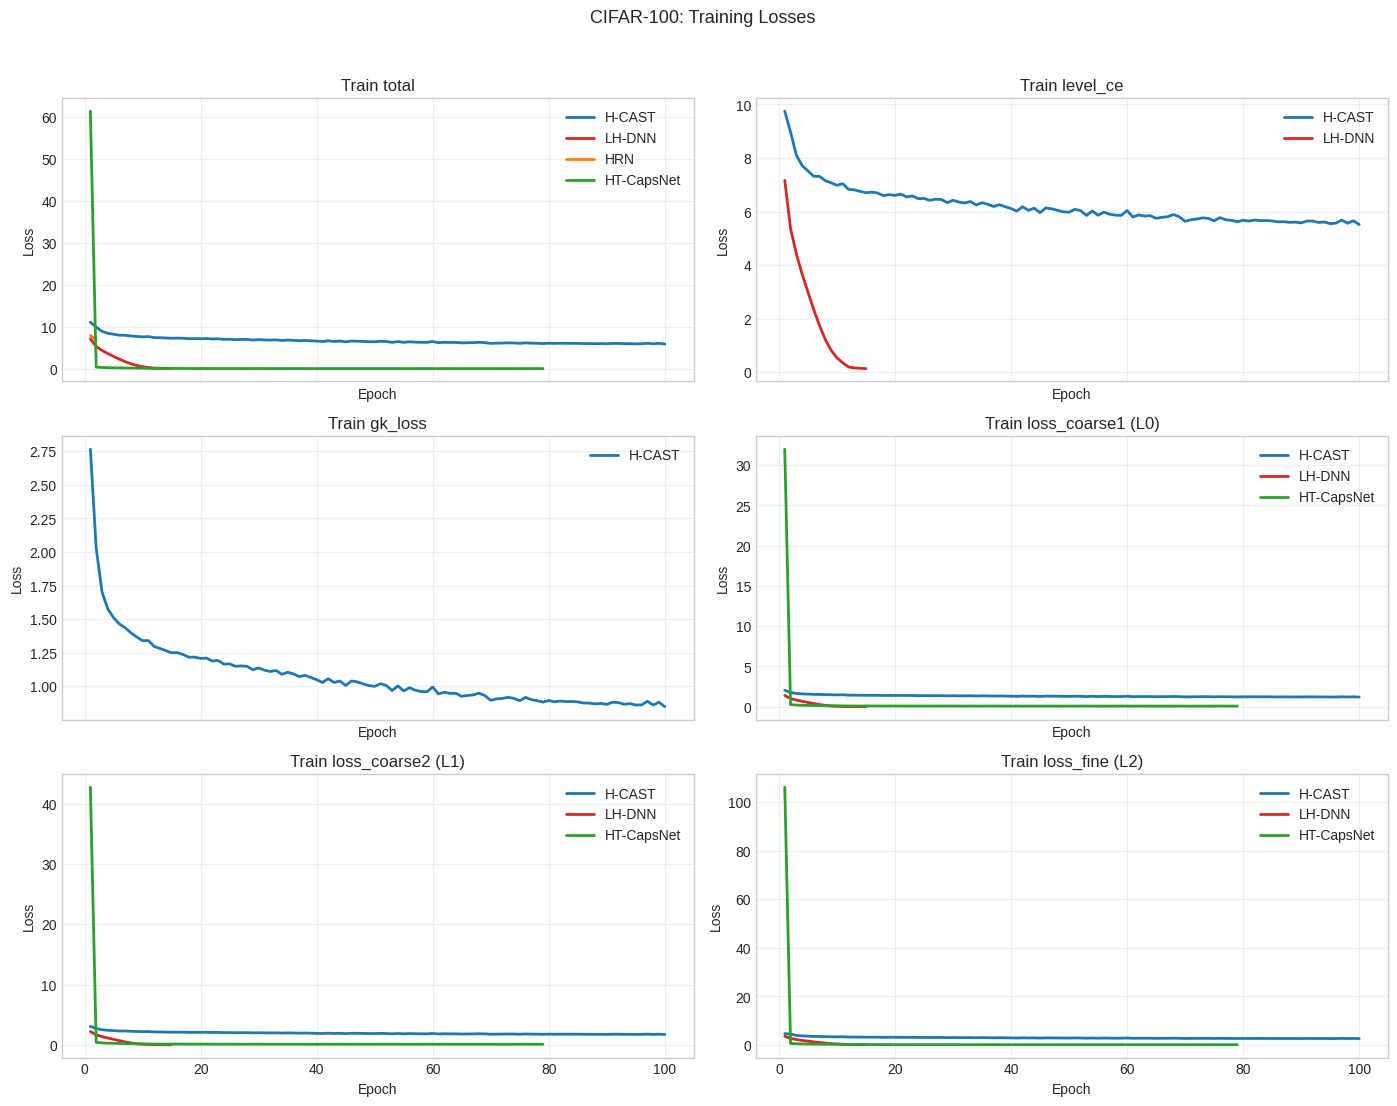

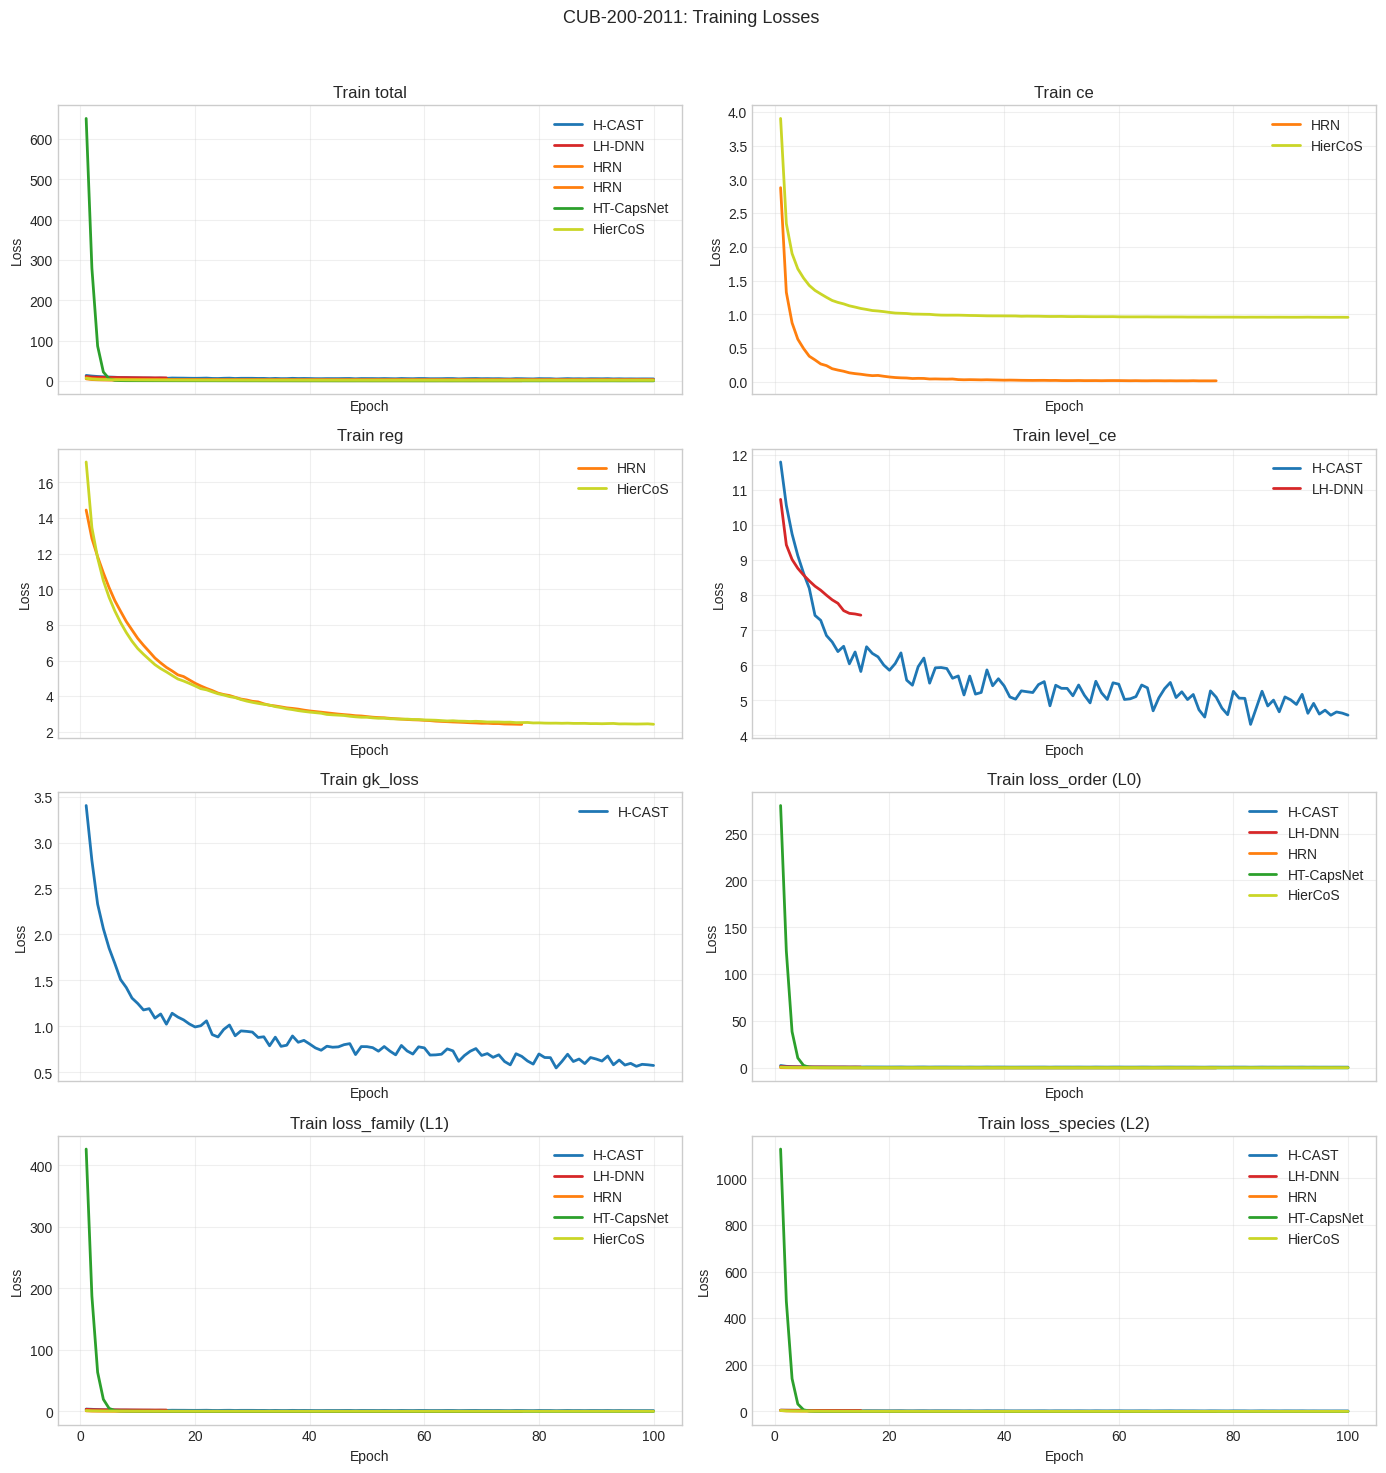

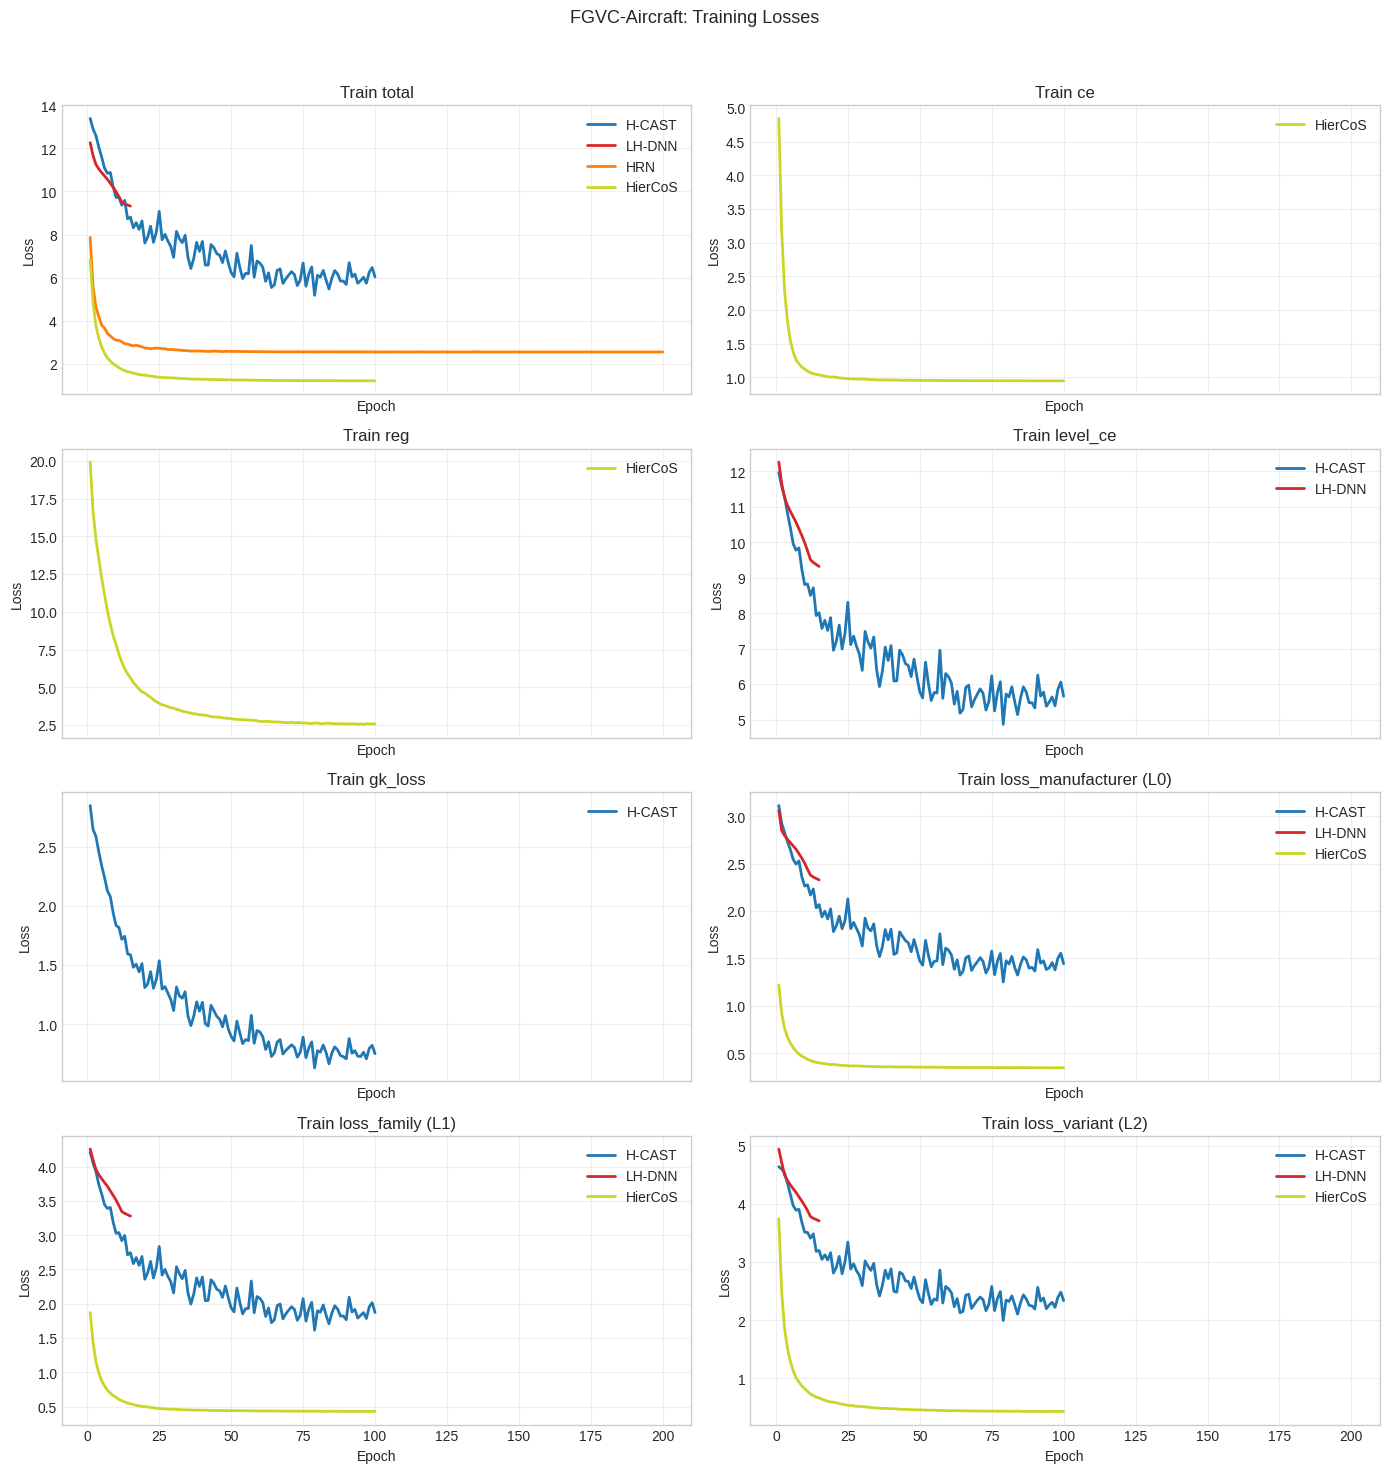

In [5]:
analysis.plot_training_losses_per_dataset()


## Per-Level Training Losses (Per Model and Dataset)

Interpretation note:
- Each chart corresponds to one selected `(model, dataset)` run.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).


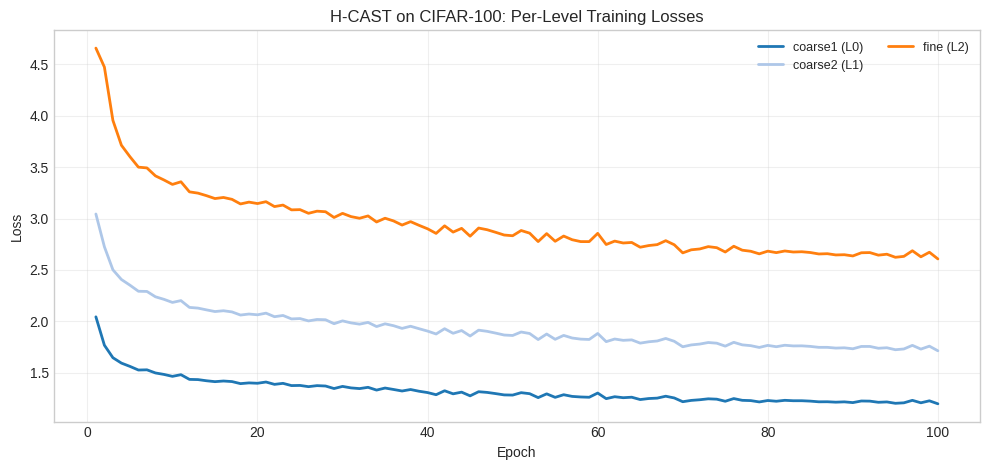

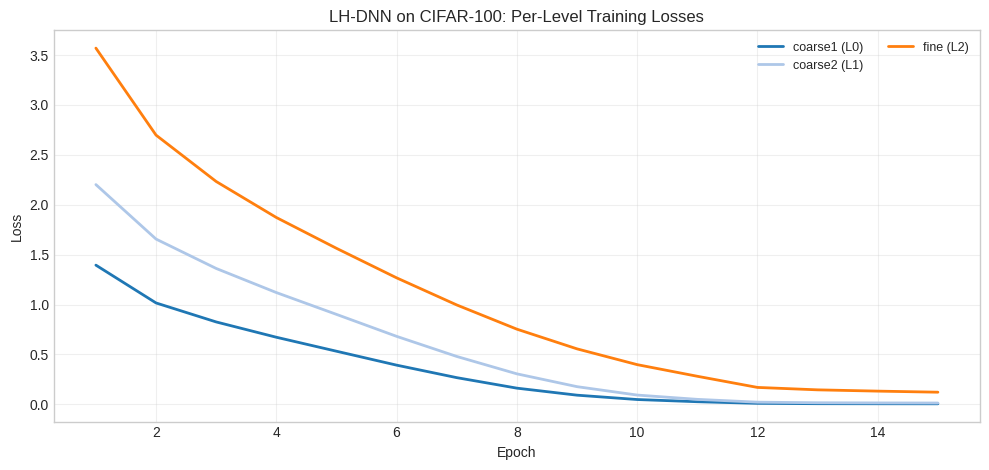

No per-level train losses for HRN on CIFAR-100


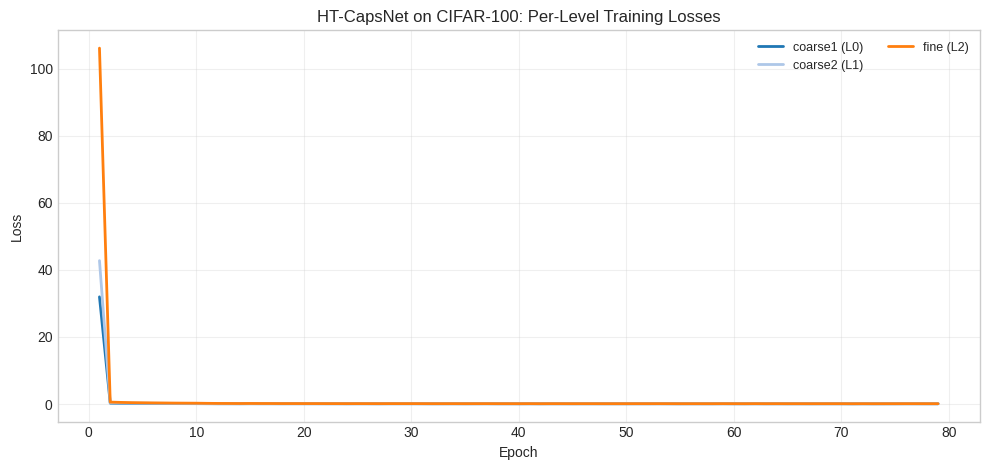

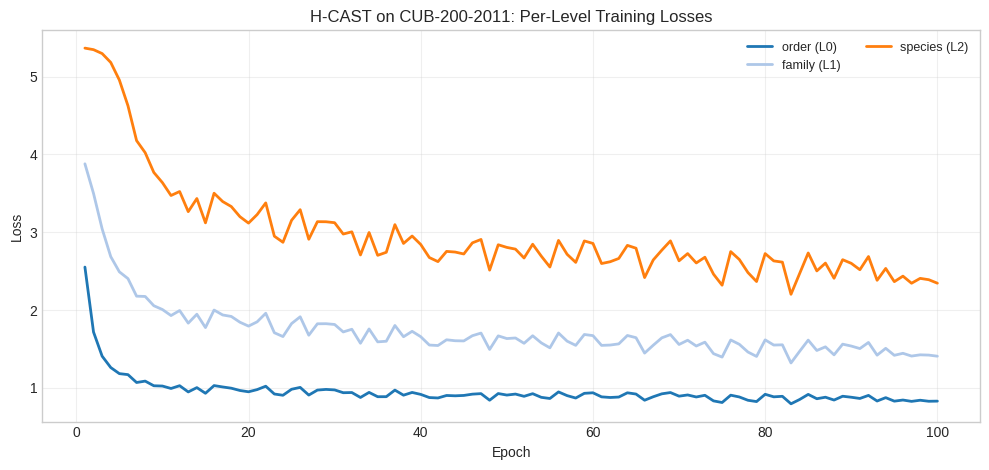

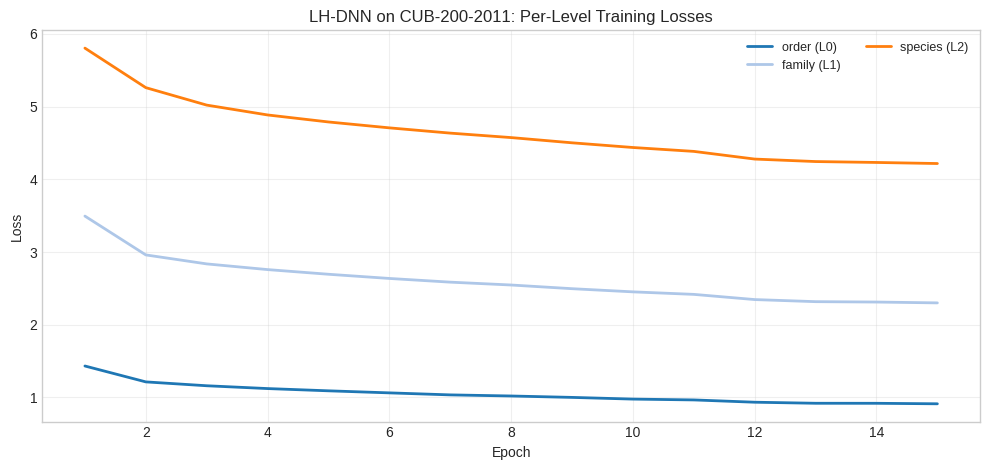

No per-level train losses for HRN on CUB-200-2011


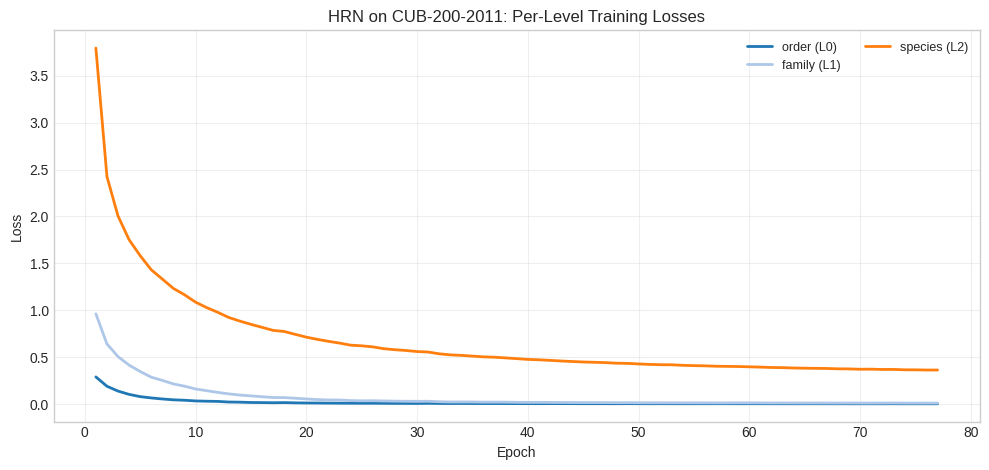

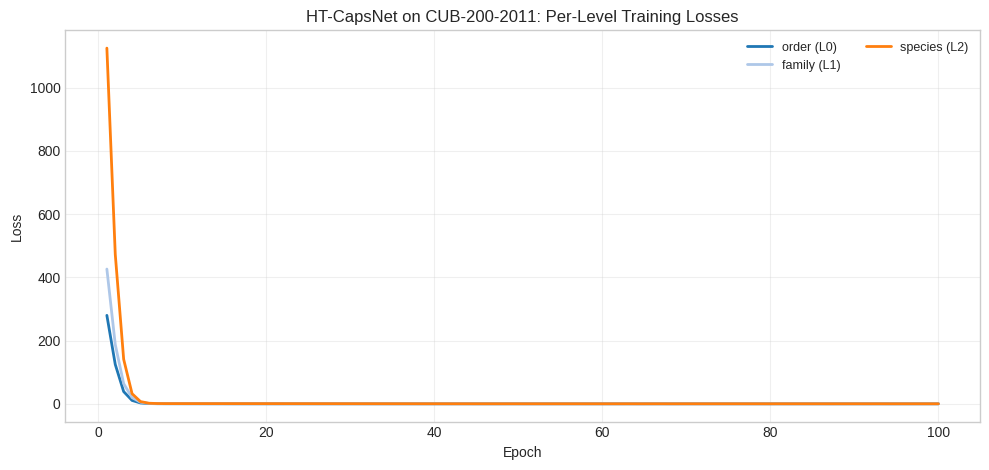

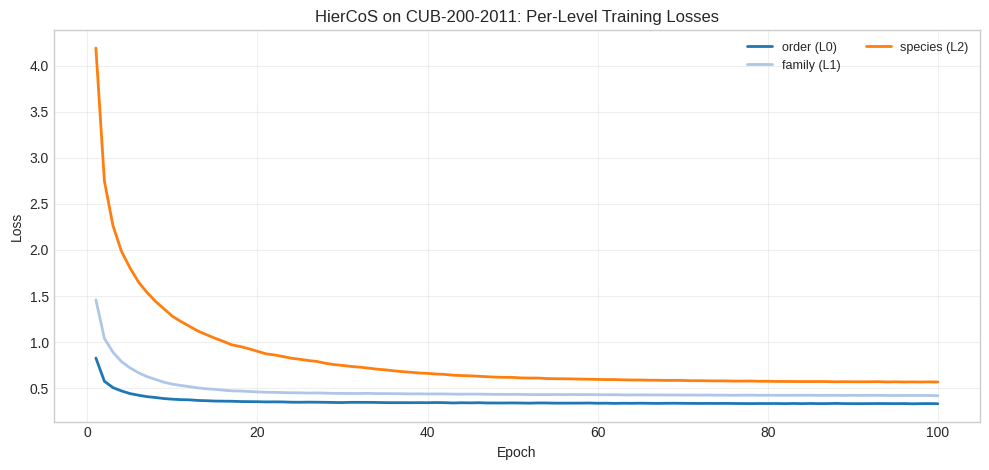

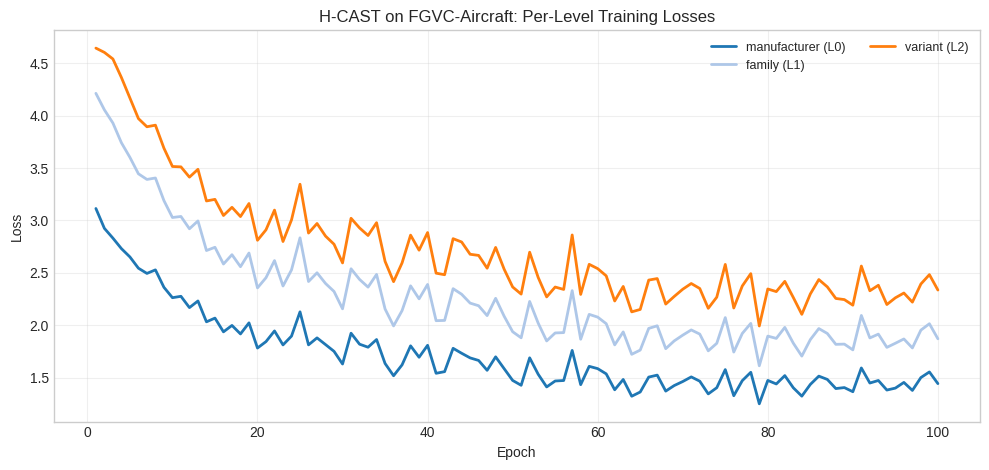

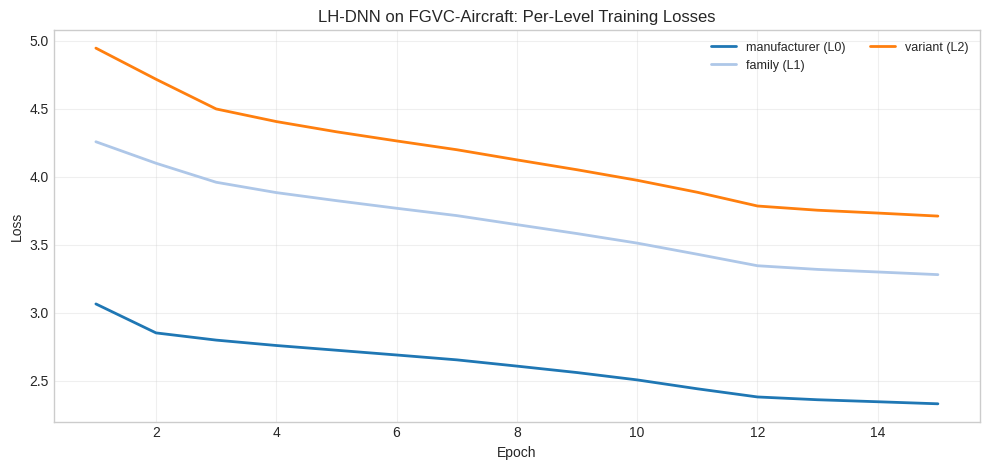

No per-level train losses for HRN on FGVC-Aircraft


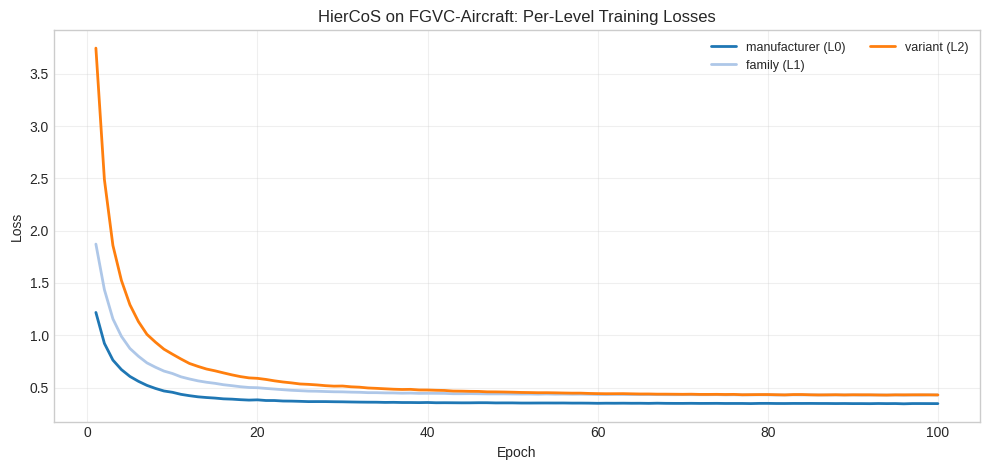

In [6]:
analysis.plot_per_run_per_level_training_losses()


## Per-Level Validation Accuracy (Top-Down and Independent)

Interpretation note:
- Solid vs dashed of the same color shows top-down vs independent for the same model.


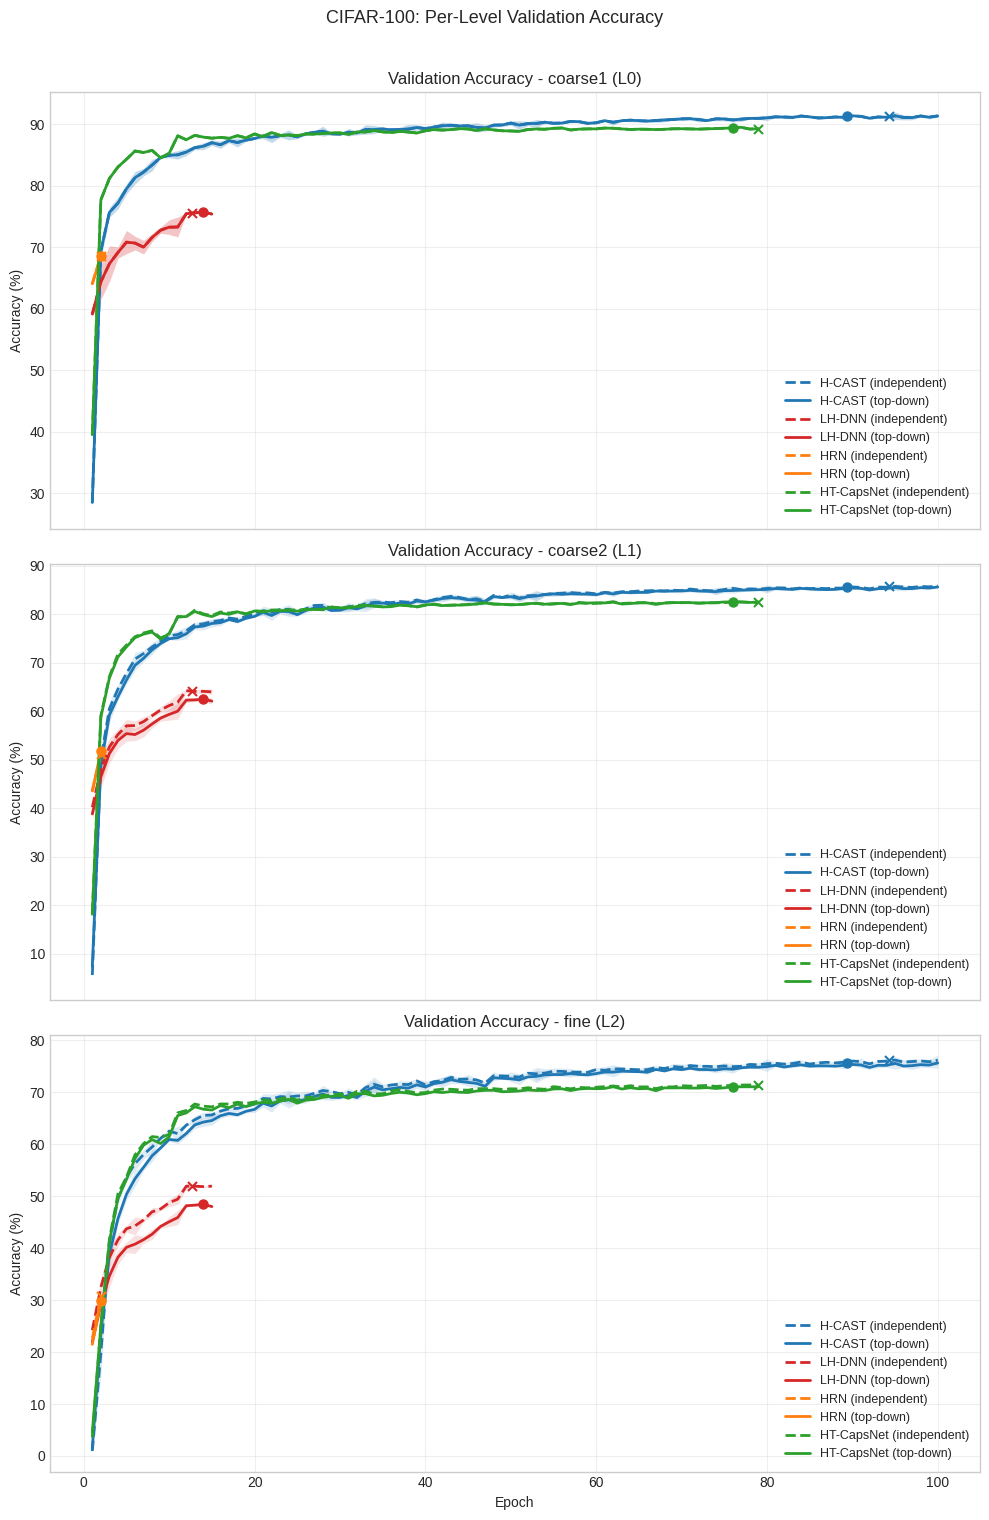

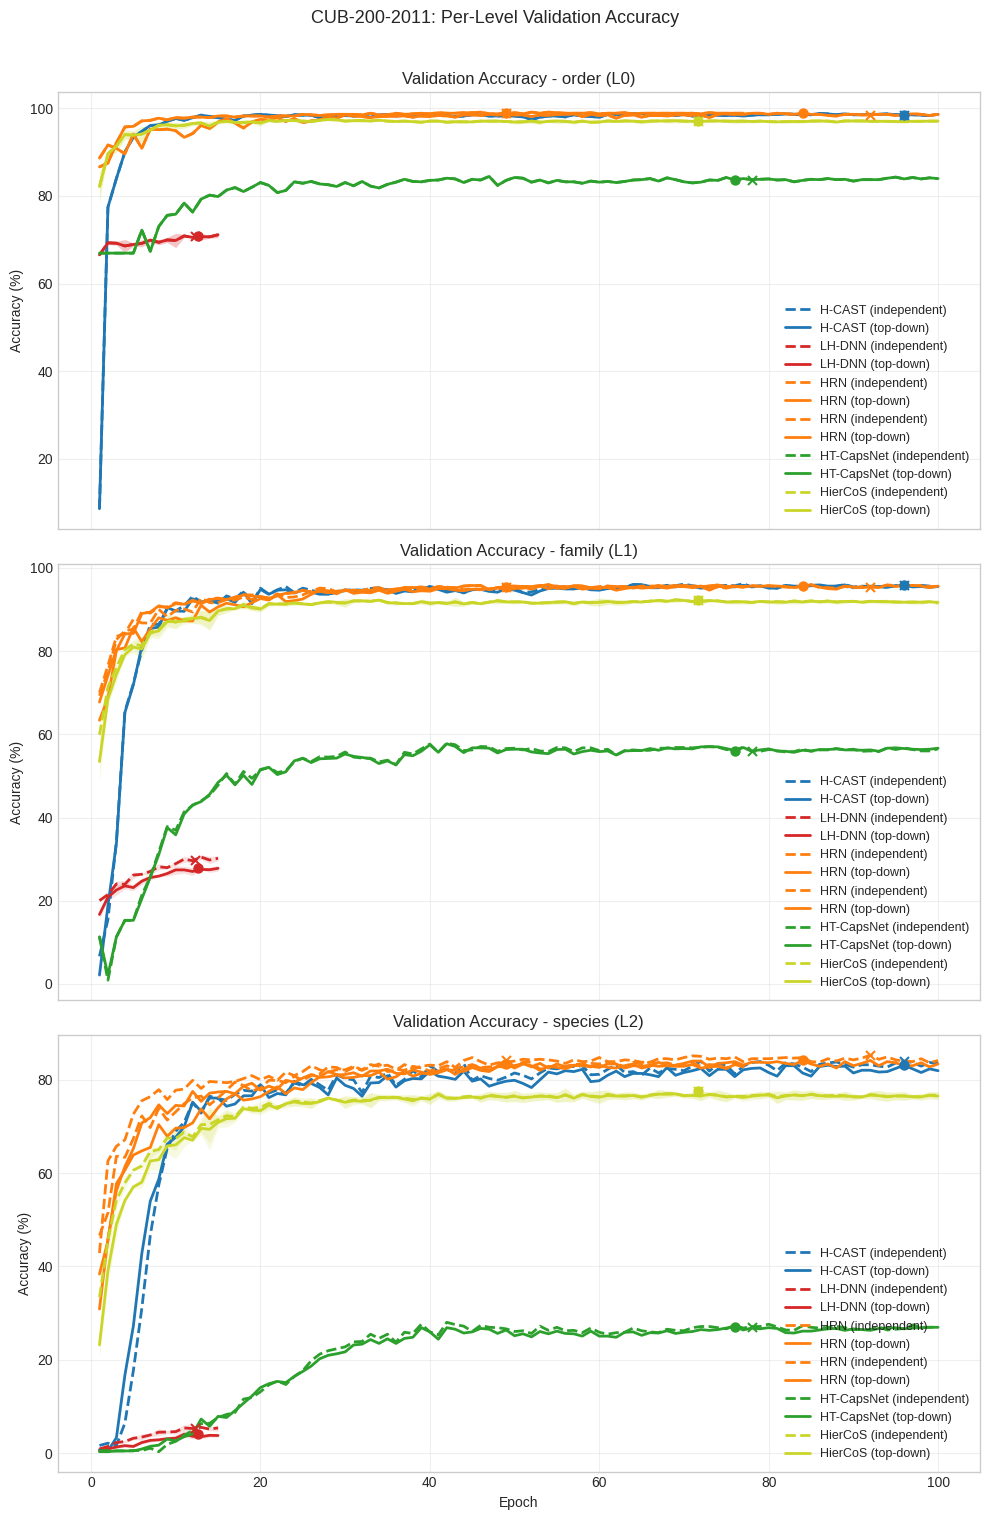

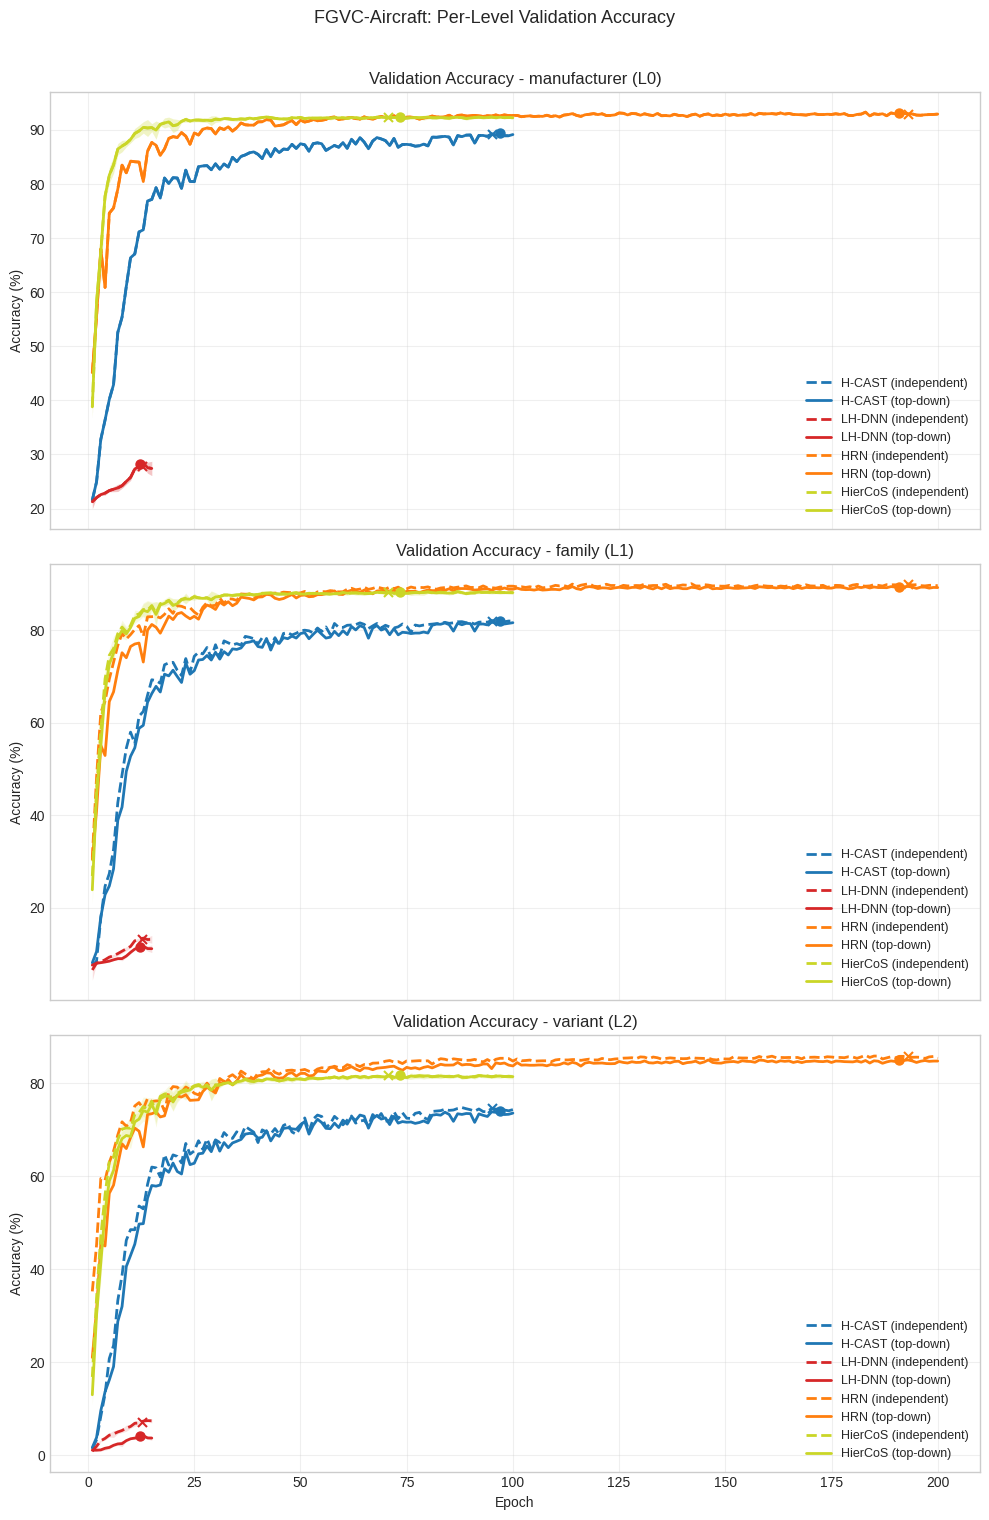

In [7]:
analysis.plot_per_level_validation_accuracy()


## Final Test Comparison Tables (Per Dataset)

The first model in each dataset section is used as baseline for deltas. When runs include mode-specific `test_results`, independent rows use the independent-best checkpoint and top-down rows use the top-down-best checkpoint.


In [8]:
analysis.show_final_test_tables()


### Dataset: `CIFAR-100`
Baseline run: **H-CAST**

| Metric | H-CAST (n=3) | LH-DNN (n=3) | HRN (n=1) | HT-CapsNet (n=1) |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 90.5 ± 13.4/98.0 ± 2.8 | 14.0 ± 0.0/12.7 ± 1.2 | n/a/n/a | n/a/n/a |
| FPA independent ↑ | **73.52% ± 0.25%** | <u>46.14% ± 0.60% (-27.38 pp)</u> | n/a | n/a |
| FPA top-down ↑ | **75.01% ± 0.25%** | <u>48.20% ± 0.32% (-26.81 pp)</u> | n/a | n/a |
| wAP independent ↑ | **78.32% ± 0.20%** | <u>55.00% ± 0.48% (-23.32 pp)</u> | n/a | n/a |
| wAP top-down ↑ | **77.58% ± 0.22%** | <u>51.97% ± 0.32% (-25.60 pp)</u> | n/a | n/a |
| TICE independent ↓ | **7.48% ± 0.25%** | <u>17.51% ± 0.47% (+10.03 pp)</u> | n/a | n/a |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | n/a | n/a |
| AHD independent ↓ | **0.506 ± 0.004** | <u>1.189 ± 0.016 (+0.683)</u> | n/a | n/a |
| AHD top-down ↓ | **0.490 ± 0.005** | <u>1.154 ± 0.009 (+0.664)</u> | n/a | n/a |
| Acc independent coarse1 (L0) ↑ | **91.00% ± 0.11%** | <u>74.63% ± 0.47% (-16.37 pp)</u> | n/a | n/a |
| Acc top-down coarse1 (L0) ↑ | **90.88% ± 0.06%** | <u>74.55% ± 0.27% (-16.33 pp)</u> | n/a | n/a |
| Acc independent coarse2 (L1) ↑ | **85.43% ± 0.01%** | <u>63.32% ± 0.52% (-22.11 pp)</u> | n/a | n/a |
| Acc top-down coarse2 (L1) ↑ | **85.10% ± 0.14%** | <u>61.81% ± 0.41% (-23.29 pp)</u> | n/a | n/a |
| Acc independent fine (L2) ↑ | **75.89% ± 0.25%** | <u>51.76% ± 0.50% (-24.12 pp)</u> | n/a | n/a |
| Acc top-down fine (L2) ↑ | **75.01% ± 0.25%** | <u>48.20% ± 0.32% (-26.81 pp)</u> | n/a | n/a |

### Dataset: `CUB-200-2011`
Baseline run: **H-CAST**

| Metric | H-CAST (n=1) | LH-DNN (n=3) | HRN (n=1) | HRN (n=1) | HT-CapsNet (n=1) | HierCoS (n=3) |
|---|---:|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 96/96 | 12.7 ± 2.1/12.3 ± 2.3 | 84/92 | n/a/n/a | n/a/n/a | 71.7 ± 16.3/71.7 ± 16.3 |
| FPA independent ↑ | <u>81.46%</u> | 2.33% ± 0.23% (-79.13 pp) | **82.67% (+1.20 pp)** | n/a | n/a | 76.15% ± 0.42% (-5.32 pp) |
| FPA top-down ↑ | <u>82.92%</u> | 3.66% ± 0.31% (-79.26 pp) | **84.31% (+1.38 pp)** | n/a | 26.30% (-56.62 pp) | 76.21% ± 0.47% (-6.71 pp) |
| wAP independent ↑ | <u>85.65%</u> | 12.64% ± 0.61% (-73.01 pp) | **86.95% (+1.30 pp)** | n/a | n/a | 79.58% ± 0.34% (-6.07 pp) |
| wAP top-down ↑ | <u>85.46%</u> | 10.99% ± 0.24% (-74.47 pp) | **86.62% (+1.16 pp)** | n/a | 33.89% (-51.57 pp) | 79.44% ± 0.40% (-6.02 pp) |
| TICE independent ↓ | 4.95% | 63.05% ± 1.97% (+58.10 pp) | <u>4.83% (-0.12 pp)</u> | n/a | n/a | **0.60% ± 0.19% (-4.35 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | n/a | **0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.259</u> | 1.996 ± 0.015 (+1.737) | **0.247 (-0.012)** | n/a | n/a | 0.366 ± 0.006 (+0.107) |
| AHD top-down ↓ | <u>0.243</u> | 1.960 ± 0.001 (+1.717) | **0.224 (-0.019)** | n/a | 2.660 (+2.417) | 0.365 ± 0.007 (+0.122) |
| Acc independent order (L0) ↑ | <u>98.40%</u> | 71.30% ± 0.54% (-27.10 pp) | **98.60% (+0.20 pp)** | n/a | n/a | 96.85% ± 0.11% (-1.56 pp) |
| Acc top-down order (L0) ↑ | <u>98.40%</u> | 71.44% ± 0.30% (-26.97 pp) | **98.60% (+0.20 pp)** | n/a | 84.10% (-14.30 pp) | 96.85% ± 0.11% (-1.56 pp) |
| Acc independent family (L1) ↑ | <u>94.50%</u> | 30.62% ± 1.09% (-63.88 pp) | **94.54% (+0.05 pp)** | n/a | n/a | 90.51% ± 0.13% (-3.99 pp) |
| Acc top-down family (L1) ↑ | <u>94.40%</u> | 28.87% ± 0.13% (-65.52 pp) | **94.68% (+0.29 pp)** | n/a | 56.61% (-37.79 pp) | 90.45% ± 0.17% (-3.95 pp) |
| Acc independent species (L2) ↑ | <u>83.14%</u> | 5.41% ± 0.55% (-77.73 pp) | **84.75% (+1.62 pp)** | n/a | n/a | 76.38% ± 0.41% (-6.76 pp) |
| Acc top-down species (L2) ↑ | <u>82.92%</u> | 3.66% ± 0.31% (-79.26 pp) | **84.31% (+1.38 pp)** | n/a | 26.30% (-56.62 pp) | 76.21% ± 0.47% (-6.71 pp) |

### Dataset: `FGVC-Aircraft`
Baseline run: **H-CAST**

| Metric | H-CAST (n=1) | LH-DNN (n=3) | HRN (n=1) | HierCoS (n=3) |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 97/95 | 12.3 ± 1.2/12.7 ± 1.5 | 191/193 | 73.3 ± 4.0/70.7 ± 11.0 |
| FPA independent ↑ | 69.24% | 1.96% ± 0.23% (-67.28 pp) | **84.54% (+15.30 pp)** | <u>81.40% ± 0.52% (+12.16 pp)</u> |
| FPA top-down ↑ | 72.31% | 3.85% ± 0.38% (-68.46 pp) | **85.92% (+13.61 pp)** | <u>81.74% ± 0.43% (+9.43 pp)</u> |
| wAP independent ↑ | 78.55% | 12.26% ± 0.20% (-66.29 pp) | **89.37% (+10.81 pp)** | <u>85.44% ± 0.37% (+6.89 pp)</u> |
| wAP top-down ↑ | 77.23% | 10.02% ± 0.44% (-67.21 pp) | **88.78% (+11.55 pp)** | <u>85.60% ± 0.28% (+8.37 pp)</u> |
| TICE independent ↓ | 13.68% | 80.71% ± 1.31% (+67.03 pp) | <u>6.80% (-6.88 pp)</u> | **0.78% ± 0.13% (-12.90 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.289 | 2.615 ± 0.004 (+1.326) | <u>0.646 (-0.644)</u> | **0.384 ± 0.008 (-0.905)** |
| AHD top-down ↓ | 1.208 | 2.576 ± 0.013 (+1.368) | <u>0.592 (-0.616)</u> | **0.378 ± 0.007 (-0.830)** |
| Acc independent manufacturer (L0) ↑ | 87.35% | 26.65% ± 0.49% (-60.70 pp) | **93.57% (+6.22 pp)** | <u>92.22% ± 0.05% (+4.87 pp)</u> |
| Acc top-down manufacturer (L0) ↑ | 87.38% | 27.02% ± 0.49% (-60.35 pp) | **93.72% (+6.34 pp)** | <u>92.20% ± 0.17% (+4.82 pp)</u> |
| Acc independent family (L1) ↑ | 81.38% | 13.42% ± 0.17% (-67.96 pp) | **91.20% (+9.82 pp)** | <u>88.10% ± 0.33% (+6.71 pp)</u> |
| Acc top-down family (L1) ↑ | 79.90% | 11.54% ± 0.57% (-68.36 pp) | **90.75% (+10.85 pp)** | <u>88.28% ± 0.18% (+8.38 pp)</u> |
| Acc independent variant (L2) ↑ | 73.93% | 7.13% ± 0.37% (-66.80 pp) | **86.82% (+12.89 pp)** | <u>81.55% ± 0.52% (+7.61 pp)</u> |
| Acc top-down variant (L2) ↑ | 72.31% | 3.85% ± 0.38% (-68.46 pp) | **85.92% (+13.61 pp)** | <u>81.74% ± 0.43% (+9.43 pp)</u> |